In [14]:
import os
import random
import shutil

# =====================================================================
# 1. KONFIGURASI DIREKTORI
# =====================================================================
# Lokasi folder sumber dataset mentah
SOURCE_NORMAL = r"D:\Project_CCTV_3\cobs\Normal"
SOURCE_VIOLENCE = r"D:\Project_CCTV_3\cobs\Violence"

# Lokasi folder tujuan untuk dataset eksternal yang akan diuji
TARGET_BASE = r"D:\Project_CCTV_3\dataset_eksternal"
TARGET_NORMAL = os.path.join(TARGET_BASE, "noFight")
TARGET_VIOLENCE = os.path.join(TARGET_BASE, "fight")

# =====================================================================
# 2. KONFIGURASI JUMLAH SAMPEL
# =====================================================================
NUM_NORMAL = 50
NUM_VIOLENCE = 40

def prepare_validation_dataset():
    """
    Fungsi untuk mengambil subset dataset secara acak, menyalin, dan 
    melakukan pelabelan ulang (re-labelling) sesuai struktur kelas model.
    """
    print("[INFO] Memulai penyiapan dataset eksternal...")
    
    # Membuat folder tujuan jika belum tersedia
    os.makedirs(TARGET_NORMAL, exist_ok=True)
    os.makedirs(TARGET_VIOLENCE, exist_ok=True)

    # Mengambil seluruh daftar file berekstensi video dari folder sumber
    normal_files = [f for f in os.listdir(SOURCE_NORMAL) if f.endswith(('.avi', '.mp4'))]
    violence_files = [f for f in os.listdir(SOURCE_VIOLENCE) if f.endswith(('.avi', '.mp4'))]

    print(f" -> Total video Normal asli ditemukan  : {len(normal_files)}")
    print(f" -> Total video Violence asli ditemukan: {len(violence_files)}")

    # Memvalidasi ketersediaan jumlah file sebelum diproses
    if len(normal_files) < NUM_NORMAL:
        print("ERROR: Jumlah video Normal tidak mencukupi untuk subset!")
        return
    if len(violence_files) < NUM_VIOLENCE:
        print("ERROR: Jumlah video Violence tidak mencukupi untuk subset!")
        return

    # Mengacak urutan elemen di dalam daftar untuk memastikan pemilihan sampel acak (Randomize)
    random.shuffle(normal_files)
    random.shuffle(violence_files)

    # Memotong (slicing) daftar sesuai dengan jumlah sampel yang dibutuhkan
    selected_normal = normal_files[:NUM_NORMAL]
    selected_violence = violence_files[:NUM_VIOLENCE]

    print(f"\n[PROSES] Menyalin dan me-relabel {NUM_NORMAL} sampel Normal...")
    for i, filename in enumerate(selected_normal, 1):
        src_path = os.path.join(SOURCE_NORMAL, filename)
        # Re-labelling menjadi format: noFight_001.avi, noFight_002.avi, dst.
        ext = os.path.splitext(filename)[1]
        new_name = f"noFight_{i:03d}{ext}"
        dst_path = os.path.join(TARGET_NORMAL, new_name)
        shutil.copy2(src_path, dst_path)

    print(f"[PROSES] Menyalin dan me-relabel {NUM_VIOLENCE} sampel Violence...")
    for i, filename in enumerate(selected_violence, 1):
        src_path = os.path.join(SOURCE_VIOLENCE, filename)
        # Re-labelling menjadi format: fight_001.avi, fight_002.avi, dst.
        ext = os.path.splitext(filename)[1]
        new_name = f"fight_{i:03d}{ext}"
        dst_path = os.path.join(TARGET_VIOLENCE, new_name)
        shutil.copy2(src_path, dst_path)

    print("\n[SELESAI] Penyiapan dataset eksternal berhasil dieksekusi!")
    print(f"[INFO] Direktori dataset baru: {TARGET_BASE}")

if __name__ == "__main__":
    prepare_validation_dataset()

[INFO] Memulai penyiapan dataset eksternal...
 -> Total video Normal asli ditemukan  : 200
 -> Total video Violence asli ditemukan: 1000

[PROSES] Menyalin dan me-relabel 50 sampel Normal...
[PROSES] Menyalin dan me-relabel 40 sampel Violence...

[SELESAI] Penyiapan dataset eksternal berhasil dieksekusi!
[INFO] Direktori dataset baru: D:\Project_CCTV_3\dataset_eksternal


In [15]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import Fight_utils_mvit

# Konfigurasi Path
DATASET_EKSTERNAL_DIR = r"D:\Project_CCTV_3\dataset_eksternal"
MODEL_PATH = "models/mvit_fight_modelb4lr0001.pth"
CLASSES_LIST = ['fight', 'noFight']
SEQUENCE_LENGTH = 16

# Fungsi Ekstraksi 16 Frame
def extract_16_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames = []
    if frame_count == 0:
        return frames
        
    skip_interval = max(int(frame_count / SEQUENCE_LENGTH), 1)
    
    for i in range(SEQUENCE_LENGTH):
        cap.set(cv2.CAP_PROP_POS_FRAMES, min(i * skip_interval, frame_count - 1))
        ret, frame = cap.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame_rgb)
        else:
            break
    cap.release()
    
    while len(frames) > 0 and len(frames) < SEQUENCE_LENGTH:
        frames.append(frames[-1])
    return frames

print("[INFO] Cell 1 berhasil di-run! Model dan fungsi siap.")

[INFO] Cell 1 berhasil di-run! Model dan fungsi siap.


In [16]:
print("[INFO] Memuat arsitektur dan bobot MViTv2...")
model = Fight_utils_mvit.loadModel(MODEL_PATH)
transform = Fight_utils_mvit.transform_()

# Variabel Global untuk Cell Selanjutnya
y_true = []
y_pred = []

for class_name in CLASSES_LIST:
    folder_path = os.path.join(DATASET_EKSTERNAL_DIR, class_name)
    if not os.path.exists(folder_path):
        print(f"Peringatan: Direktori {folder_path} tidak ditemukan!")
        continue
        
    video_files = [f for f in os.listdir(folder_path) if f.endswith(('.mp4', '.avi'))]
    print(f"\n[INFO] Memproses kelas: '{class_name}' ({len(video_files)} sampel)...")
    
    for i, video_file in enumerate(video_files, 1):
        video_path = os.path.join(folder_path, video_file)
        frames = extract_16_frames(video_path)
        
        if len(frames) == SEQUENCE_LENGTH:
            clips = [transform(image=f)['image'] for f in frames]
            predicted_class = Fight_utils_mvit.PredTopKClass(1, clips, model)
            
            y_true.append(class_name)
            y_pred.append(predicted_class)
            
        if i % 10 == 0 or i == len(video_files):
            print(f"       -> {i}/{len(video_files)} video selesai...")

print("\n[INFO] Cell 2 selesai! Data prediksi berhasil dikumpulkan.")

[INFO] Memuat arsitektur dan bobot MViTv2...


d:\Project_CCTV_3\Fight_utils_mvit.py:12: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  A.Resize(256, 256, always_apply=True),
d:\Project_CCTV_3\Fight_utils_mvit.py:13: UserWarning: Argument(s) 'always_apply' are not valid for transform CenterCrop
  A.CenterCrop(224, 224, always_apply=True),
d:\Project_CCTV_3\Fight_utils_mvit.py:14: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  A.Normalize(



[INFO] Memproses kelas: 'fight' (40 sampel)...
       -> 10/40 video selesai...
       -> 20/40 video selesai...
       -> 30/40 video selesai...
       -> 40/40 video selesai...

[INFO] Memproses kelas: 'noFight' (50 sampel)...
       -> 10/50 video selesai...
       -> 20/50 video selesai...
       -> 30/50 video selesai...
       -> 40/50 video selesai...
       -> 50/50 video selesai...

[INFO] Cell 2 selesai! Data prediksi berhasil dikumpulkan.


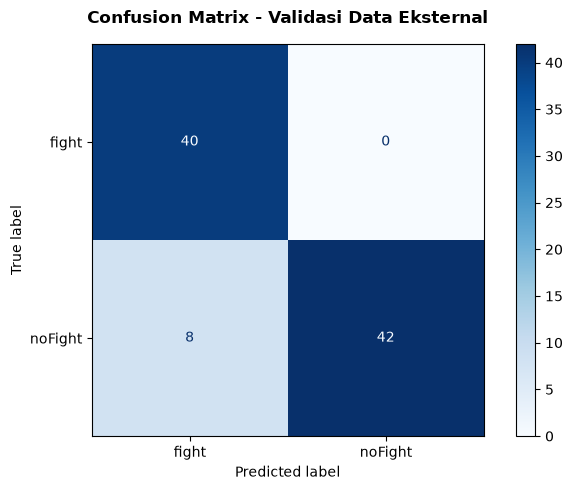

In [17]:
# Membuat Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=CLASSES_LIST)

fig, ax = plt.subplots(figsize=(7, 5), dpi=100)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES_LIST)
disp.plot(cmap=plt.cm.Blues, ax=ax)

ax.set_title('Confusion Matrix - Validasi Data Eksternal', fontweight='bold', pad=15)
plt.tight_layout()

# Menampilkan langsung di Notebook
plt.show()

In [18]:
print("="*60)
print("LAPORAN EVALUASI DATASET EKSTERNAL (UNSEEN DATA)")
print("="*60)
report = classification_report(y_true, y_pred, target_names=CLASSES_LIST, digits=4)
print(report)
print("="*60)

LAPORAN EVALUASI DATASET EKSTERNAL (UNSEEN DATA)
              precision    recall  f1-score   support

       fight     0.8333    1.0000    0.9091        40
     noFight     1.0000    0.8400    0.9130        50

    accuracy                         0.9111        90
   macro avg     0.9167    0.9200    0.9111        90
weighted avg     0.9259    0.9111    0.9113        90



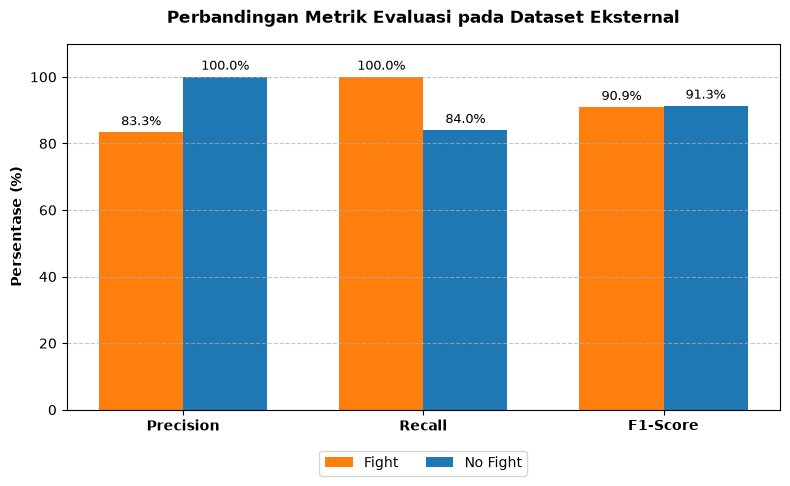

In [19]:
# Mengambil data dictionary dari classification report
report_dict = classification_report(y_true, y_pred, target_names=CLASSES_LIST, output_dict=True)

# Menyiapkan data untuk di-plot
metrics = ['precision', 'recall', 'f1-score']
fight_scores = [report_dict['fight'][m] * 100 for m in metrics]
nofight_scores = [report_dict['noFight'][m] * 100 for m in metrics]

x = np.arange(len(metrics))  # Lokasi label di sumbu x
width = 0.35  # Lebar batang grafik

fig, ax = plt.subplots(figsize=(8, 5), dpi=100)
rects1 = ax.bar(x - width/2, fight_scores, width, label='Fight', color='#ff7f0e')
rects2 = ax.bar(x + width/2, nofight_scores, width, label='No Fight', color='#1f77b4')

# Kustomisasi Tampilan Grafik
ax.set_ylabel('Persentase (%)', fontweight='bold')
ax.set_title('Perbandingan Metrik Evaluasi pada Dataset Eksternal', fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(['Precision', 'Recall', 'F1-Score'], fontweight='bold')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Fungsi untuk nambahin label angka di atas batang
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # offset vertikal
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()